# Connecting to the database

In [1]:
import psycopg2
import pandas as pd

In [2]:
db_params = {
    'host': '194.171.191.226',
    'port': '6379',
    'database': 'postgres',
    'user': 'group15',
    'password': 'blockd_2024group15_73'
}

In [3]:
conn_psycopg2 = psycopg2.connect(**db_params)
cursor = conn_psycopg2.cursor()

# Displaying the data

In [4]:
# Execute SQL query to select the whole dataset
query = '''
    SELECT * 
    FROM group15_warehouse.accident_data_17_23
'''

cursor.execute(query)

# Fetch all rows
new_accident_rows = cursor.fetchall()

# Fetch column names
column_names = [desc[0] for desc in cursor.description]

# Convert the fetched data into a pandas DataFrame
new_accidents = pd.DataFrame(new_accident_rows, columns=column_names)

display(new_accidents)

,Year,Accident severity,municipality,town,First Mode of Transport,Second mode of Transport,Area Type,Light condition,Road Location,Road condition,Road surface,Road situation,Speed limit,street,weather,accidents
0,2017,Fatal,Breda,BREDA,Car,Pedestrian,Urban area,Darkness,Intersection,Wet/damp,Brick,Bend,30 km/h,Valkeniersplein,Rain,1
1,2017,Fatal,Breda,BREDA,Lorry,Other,Urban area,Daylight,Intersection,Wet/damp,Brick,Intersection - 4 arms,50 km/h,Markendaalseweg,Dry,1
2,2017,Fatal,Breda,BREDA,Lorry,Other,Urban area,Daylight,Road section,Dry,Asphalt (other),Straight road,50 km/h,Academiesingel,Dry,1
3,2017,Injured,Breda,BAVEL,Car,Lorry,Rural area,Darkness,Road section,Wet/damp,Asphalt (other),Bend,120 km/h,KP ST.ANNABOSCH,Dry,1
4,2017,Injured,Breda,BAVEL,Car,Other,Rural area,Darkness,Road section,Wet/damp,Porous asphalt,Straight road,130 km/h,RYKSWG,Rain,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6897,2023,Fatal,Breda,BREDA,Car,Moped,Urban area,Daylight,Road section,Dry,Asphalt (other),Straight road,50 km/h,Terheijdenseweg,Dry,1
6898,2023,Fatal,Breda,BREDA,Car,Car,Urban area,Darkness,Intersection,Dry,Asphalt (other),Intersection - 4 arms,70 km/h,Rijsbergseweg,Dry,1
6899,2023,Fatal,Breda,BREDA,Other,Other,Rural area,Daylight,Road section,Wet/damp,Porous asphalt,Straight road,100 km/h,RYKSWG,Dry,1
6900,2023,Fatal,Breda,PRINSENBEEK,Car,Car,Rural area,Darkness,Road section,Dry,Porous asphalt,Straight road,130 km/h,RYKSWG,Dry,1


<Axes: >

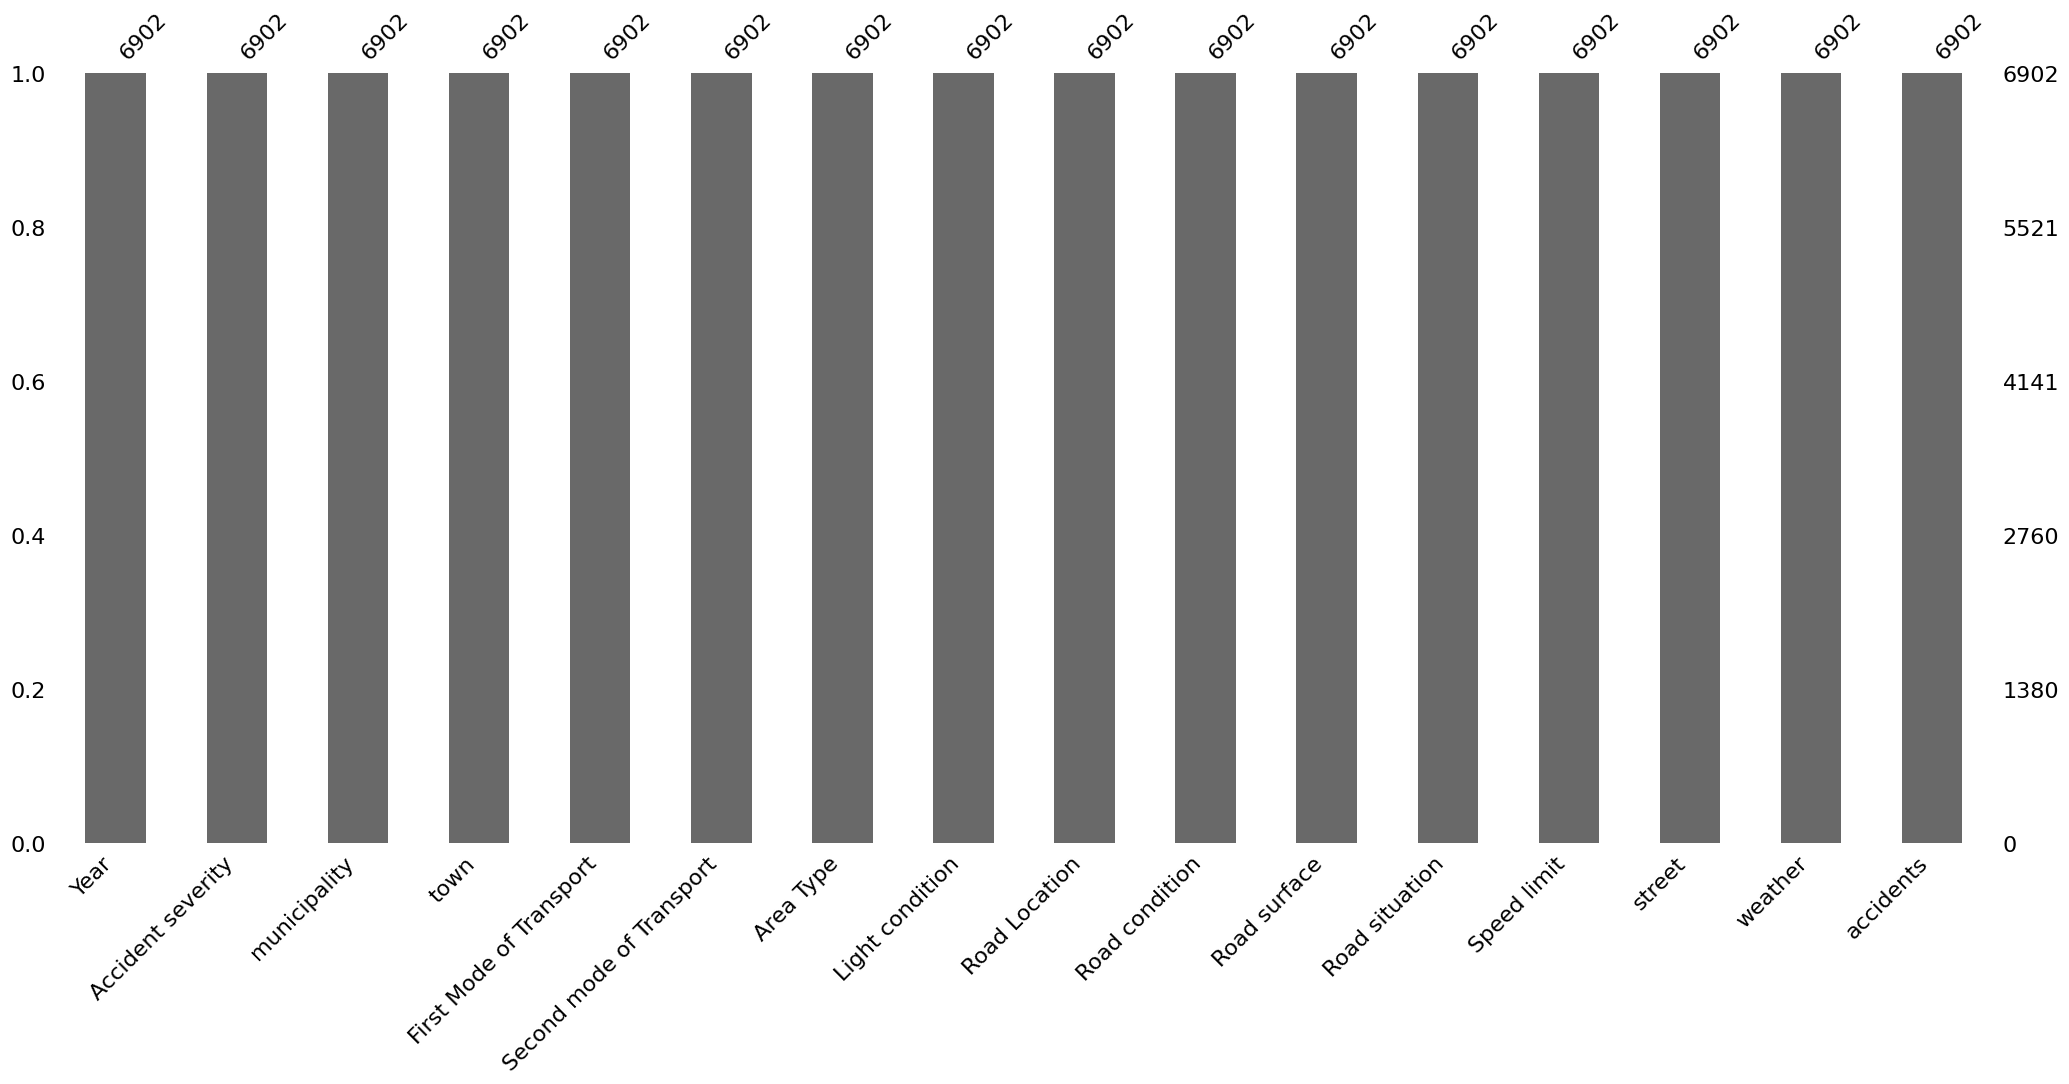

In [5]:
import psycopg2
import pandas as pd
import missingno as msno

# Visualize missing values using missingno
msno.bar(new_accidents)

In [6]:
# Print details of the dataset
print("Data Types:")
print(new_accidents.info())

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6902 entries, 0 to 6901
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Year                      6902 non-null   int64 
 1   Accident severity         6902 non-null   object
 2   municipality              6902 non-null   object
 3   town                      6902 non-null   object
 4   First Mode of Transport   6902 non-null   object
 5   Second mode of Transport  6902 non-null   object
 6   Area Type                 6902 non-null   object
 7   Light condition           6902 non-null   object
 8   Road Location             6902 non-null   object
 9   Road condition            6902 non-null   object
 10  Road surface              6902 non-null   object
 11  Road situation            6902 non-null   object
 12  Speed limit               6902 non-null   object
 13  street                    6902 non-null   object
 14  weather     

In [7]:
# Get value counts for each column
value_counts_per_column = {col: new_accidents[col].value_counts() for col in new_accidents.columns}

# Display the value counts for each column
for column, counts in value_counts_per_column.items():
    print(f"Value counts for column '{column}':")
    print(counts)
    print()

Value counts for column 'Year':
Year
2017    1274
2018    1224
2019    1181
2022    1146
2021    1084
2020     985
2023       8
Name: count, dtype: int64

Value counts for column 'Accident severity':
Accident severity
Material Damage Only    5916
Injured                  936
Fatal                     50
Name: count, dtype: int64

Value counts for column 'municipality':
municipality
Breda    6902
Name: count, dtype: int64

Value counts for column 'town':
town
BREDA          5935
PRINSENBEEK     416
BAVEL           296
TETERINGEN      139
ULVENHOUT       113
GALDER            2
ETTEN-LEUR        1
Name: count, dtype: int64

Value counts for column 'First Mode of Transport':
First Mode of Transport
Car              4350
-                 853
Delivery van      496
Moped             362
Lorry             240
Bicycle           181
Light-moped       166
Motorcycle        106
Other              83
Bus                37
Other vehicle      22
Pedestrian          6
Name: count, dtype: int64

Valu

In [8]:
# Specify numeric columns
numeric_columns = ['Year', 'accidents']

# Describe numeric columns
numeric_stats = new_accidents[numeric_columns].describe()
print("Summary statistics for numeric columns:")
print(numeric_stats)

Summary statistics for numeric columns:
              Year    accidents
count  6902.000000  6902.000000
mean   2019.413069     1.390611
std       1.740494     4.276200
min    2017.000000     1.000000
25%    2018.000000     1.000000
50%    2019.000000     1.000000
75%    2021.000000     1.000000
max    2023.000000   151.000000


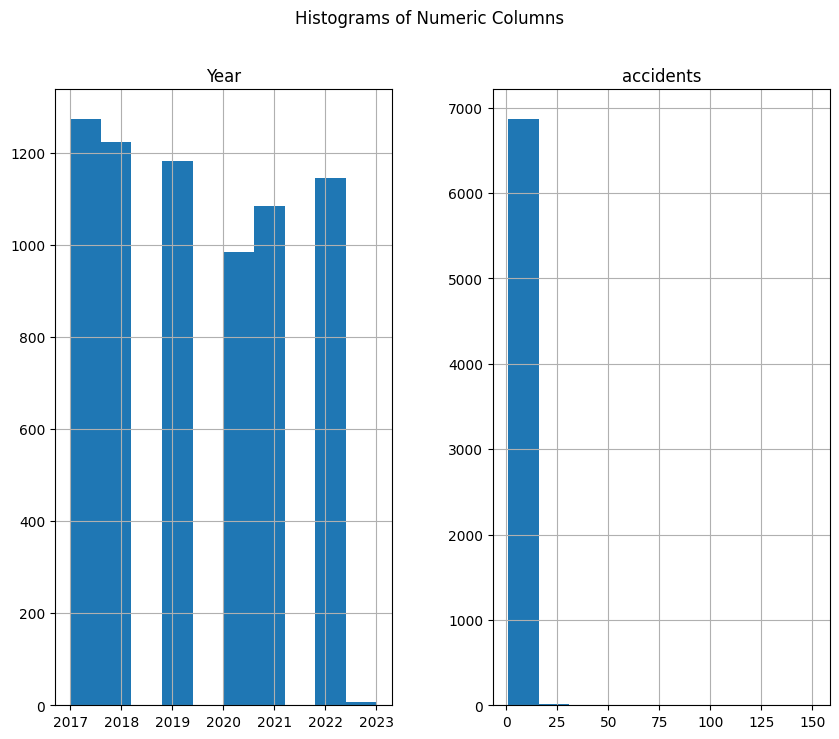

In [9]:
import matplotlib.pyplot as plt

# Plot histograms for numeric columns
new_accidents[numeric_columns].hist(figsize=(10, 8))
plt.suptitle('Histograms of Numeric Columns')
plt.show()

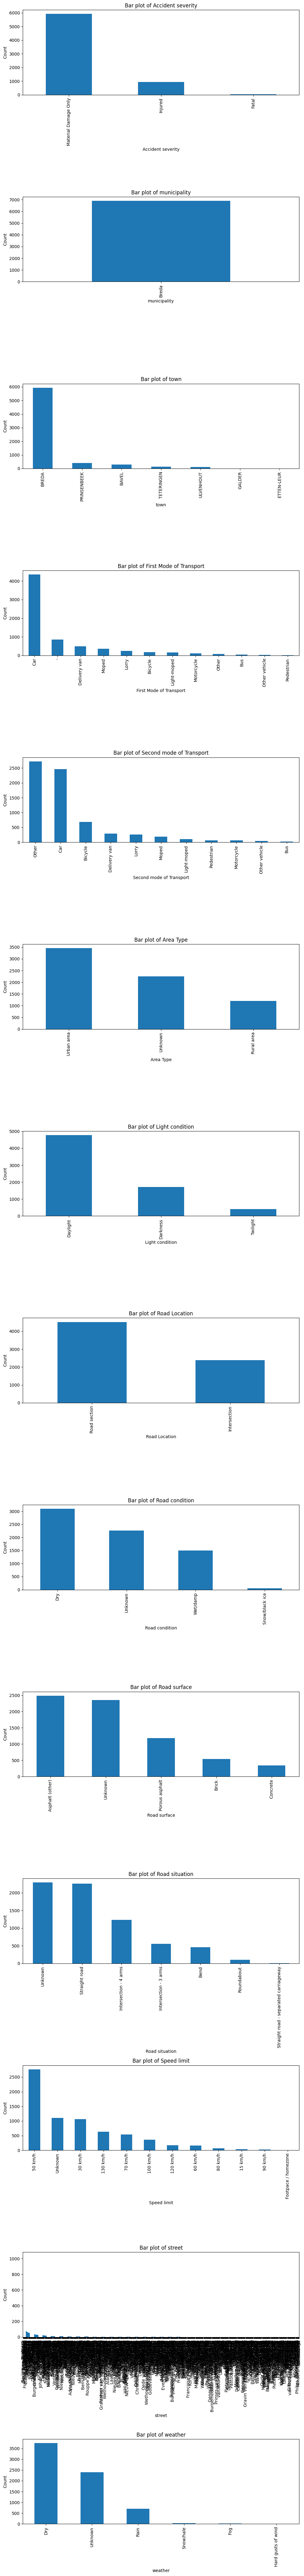

In [10]:
# Specify categorical columns
import matplotlib.pyplot as plt

categorical_columns = ['Accident severity', 'municipality', 'town', 
                       'First Mode of Transport', 'Second mode of Transport', 
                       'Area Type', 'Light condition', 'Road Location', 
                       'Road condition', 'Road surface', 'Road situation', 
                       'Speed limit', 'street', 'weather']

# Plot bar charts for categorical columns
fig, axes = plt.subplots(len(categorical_columns), 1, figsize=(10, 6 * len(categorical_columns)))

for i, col in enumerate(categorical_columns):
    new_accidents[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Bar plot of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Preprocessing steps

In [11]:
# Convert all column names to capitalized format
new_accidents = new_accidents.rename(columns=lambda x: x.capitalize())

# Display the updated DataFrame
print("DataFrame with capitalized column names:")
display(new_accidents)

DataFrame with capitalized column names:


,Year,Accident severity,Municipality,Town,First mode of transport,Second mode of transport,Area type,Light condition,Road location,Road condition,Road surface,Road situation,Speed limit,Street,Weather,Accidents
0,2017,Fatal,Breda,BREDA,Car,Pedestrian,Urban area,Darkness,Intersection,Wet/damp,Brick,Bend,30 km/h,Valkeniersplein,Rain,1
1,2017,Fatal,Breda,BREDA,Lorry,Other,Urban area,Daylight,Intersection,Wet/damp,Brick,Intersection - 4 arms,50 km/h,Markendaalseweg,Dry,1
2,2017,Fatal,Breda,BREDA,Lorry,Other,Urban area,Daylight,Road section,Dry,Asphalt (other),Straight road,50 km/h,Academiesingel,Dry,1
3,2017,Injured,Breda,BAVEL,Car,Lorry,Rural area,Darkness,Road section,Wet/damp,Asphalt (other),Bend,120 km/h,KP ST.ANNABOSCH,Dry,1
4,2017,Injured,Breda,BAVEL,Car,Other,Rural area,Darkness,Road section,Wet/damp,Porous asphalt,Straight road,130 km/h,RYKSWG,Rain,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6897,2023,Fatal,Breda,BREDA,Car,Moped,Urban area,Daylight,Road section,Dry,Asphalt (other),Straight road,50 km/h,Terheijdenseweg,Dry,1
6898,2023,Fatal,Breda,BREDA,Car,Car,Urban area,Darkness,Intersection,Dry,Asphalt (other),Intersection - 4 arms,70 km/h,Rijsbergseweg,Dry,1
6899,2023,Fatal,Breda,BREDA,Other,Other,Rural area,Daylight,Road section,Wet/damp,Porous asphalt,Straight road,100 km/h,RYKSWG,Dry,1
6900,2023,Fatal,Breda,PRINSENBEEK,Car,Car,Rural area,Darkness,Road section,Dry,Porous asphalt,Straight road,130 km/h,RYKSWG,Dry,1


In [12]:
# Handling missing values
missing_values = new_accidents.isnull().sum()
print("Missing values:")
print(missing_values)

Missing values:
Year                        0
Accident severity           0
Municipality                0
Town                        0
First mode of transport     0
Second mode of transport    0
Area type                   0
Light condition             0
Road location               0
Road condition              0
Road surface                0
Road situation              0
Speed limit                 0
Street                      0
Weather                     0
Accidents                   0
dtype: int64


In [13]:
# Removing duplicates
new_accidents.drop_duplicates(inplace=True)

In [14]:
# Dropping unnecessary columns
new_accidents = new_accidents.drop(columns=['Municipality'])

In [15]:
# Make changes in variable values
# Replace 'Other vehicle' and '-' with 'Other' in 'First Mode of Transport'
new_accidents['First mode of transport'] = new_accidents['First mode of transport'].replace({'Other vehicle': 'Other', '-': 'Other'})

# Replace 'Other vehicle' with 'Other' in 'Second mode of Transport'
new_accidents['Second mode of transport'] = new_accidents['Second mode of transport'].replace({'Other vehicle': 'Other'})

In [16]:
# Handling textual data inconsistencies
new_accidents['Town'] = new_accidents['Town'].str.capitalize()

In [17]:
# Converting categorical variables to category type
categorical_cols = ['Accident severity', 'Town', 'First mode of transport', 'Second mode of transport',
                    'Area type', 'Light condition', 'Road location', 'Road condition', 'Road surface', 'Road situation', 'Speed limit', 'Street', 'Weather']

for col in categorical_cols:
    new_accidents[col] = new_accidents[col].astype('category')

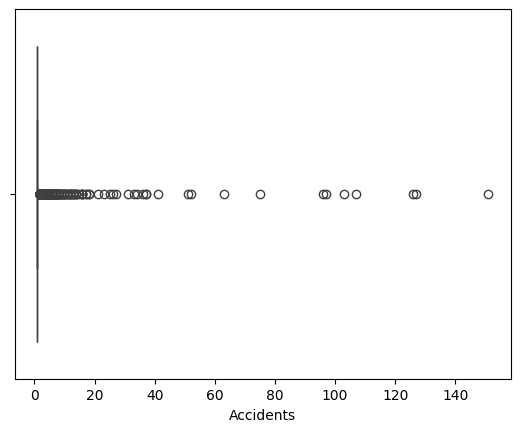

In [18]:
# Visualising outliers
import seaborn as sns
sns.boxplot(x=new_accidents['Accidents'])
plt.show()

In [19]:
import numpy as np

# Define a function to detect outliers using IQR
def detect_outliers(df, columns):
    outliers_indices = []
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outliers_indices.extend(outliers.index)
    return list(set(outliers_indices))

# Specify columns to check for outliers (numeric columns)
numeric_columns = ['Year', 'Accidents'] 

# Detect outliers
outlier_indices = detect_outliers(new_accidents, numeric_columns)

print("Rows corresponding to outliers:")
display(new_accidents.loc[outlier_indices].head(20))

Rows corresponding to outliers:


,Year,Accident severity,Town,First mode of transport,Second mode of transport,Area type,Light condition,Road location,Road condition,Road surface,Road situation,Speed limit,Street,Weather,Accidents
2050,2018,Material Damage Only,Breda,Car,Other,Rural area,Darkness,Road section,Dry,Porous asphalt,Straight road,130 km/h,RYKSWG,Dry,5
4099,2020,Material Damage Only,Breda,Car,Car,Urban area,Daylight,Road section,Dry,Porous asphalt,Straight road,70 km/h,Backer en Ruebweg,Dry,2
2053,2018,Material Damage Only,Breda,Car,Other,Rural area,Darkness,Road section,Dry,Asphalt (other),Straight road,130 km/h,RYKSWG,Dry,2
2061,2018,Material Damage Only,Breda,Car,Other,Rural area,Darkness,Road section,Wet/damp,Asphalt (other),Bend,130 km/h,RYKSWG,Dry,3
2075,2018,Material Damage Only,Breda,Car,Other,Unknown,Daylight,Road section,Unknown,Unknown,Unknown,Unknown,BREDA 15,Unknown,3
2076,2018,Material Damage Only,Breda,Car,Other,Unknown,Daylight,Road section,Unknown,Unknown,Unknown,Unknown,BREDA-WEST 16,Unknown,3
4128,2020,Material Damage Only,Breda,Car,Car,Urban area,Daylight,Road section,Wet/damp,Asphalt (other),Straight road,50 km/h,Kapittelweg,Rain,2
6177,2022,Material Damage Only,Breda,Car,Car,Urban area,Daylight,Intersection,Dry,Asphalt (other),Intersection - 3 arms,50 km/h,Emerparklaan,Dry,2
4130,2020,Material Damage Only,Breda,Car,Car,Urban area,Daylight,Road section,Wet/damp,Asphalt (other),Straight road,50 km/h,Westerhagelaan,Rain,2
2084,2018,Material Damage Only,Breda,Car,Other,Unknown,Daylight,Road section,Unknown,Unknown,Unknown,Unknown,Franklin Rooseveltlaan,Unknown,2


# EDA and Visualisation

## Univariate Analysis

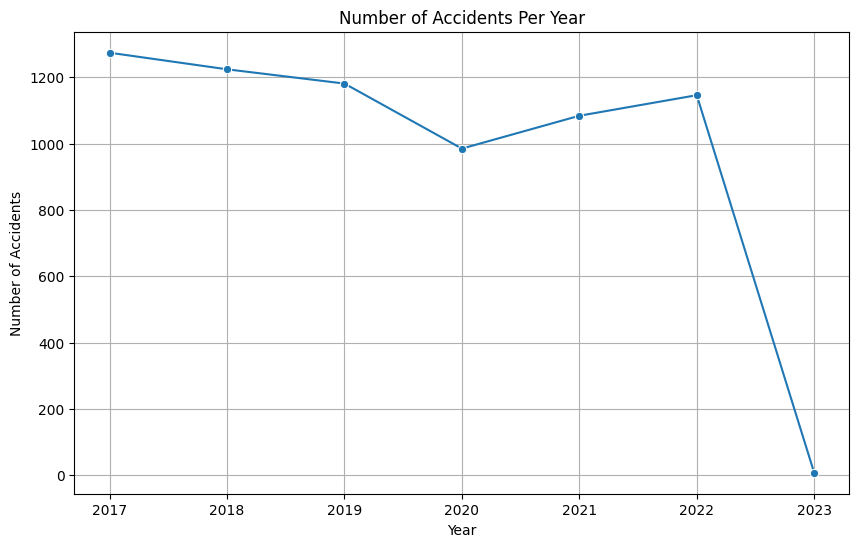

In [20]:
# Distribution of Accidents Over Years
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the number of accidents per year
accidents_per_year = new_accidents['Year'].value_counts().sort_index()

# Plotting the line chart
plt.figure(figsize=(10, 6))
sns.lineplot(x=accidents_per_year.index, y=accidents_per_year.values, marker='o')
plt.title('Number of Accidents Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.grid(True)
plt.show()

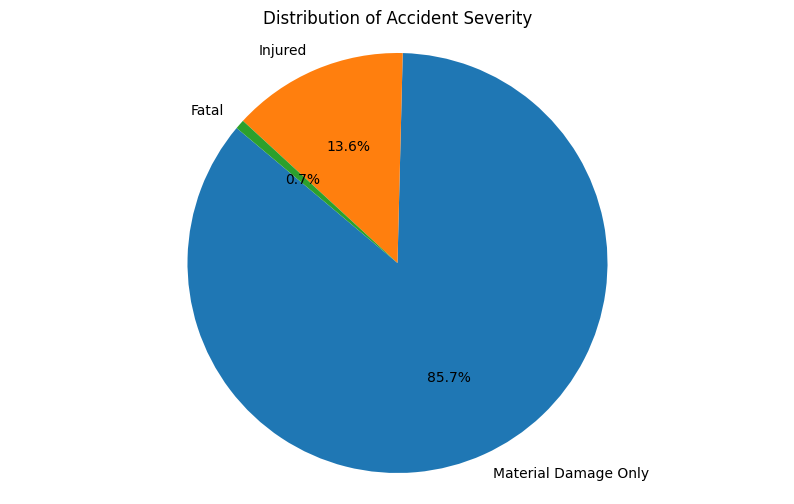

In [21]:
# Accident Severity Distribution
import matplotlib.pyplot as plt

# Calculate the number of accidents per severity
severity_counts = new_accidents['Accident severity'].value_counts()

# Plotting the pie chart
plt.figure(figsize=(10, 6))
plt.pie(severity_counts, labels=severity_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Accident Severity')
plt.axis('equal') 
plt.show()


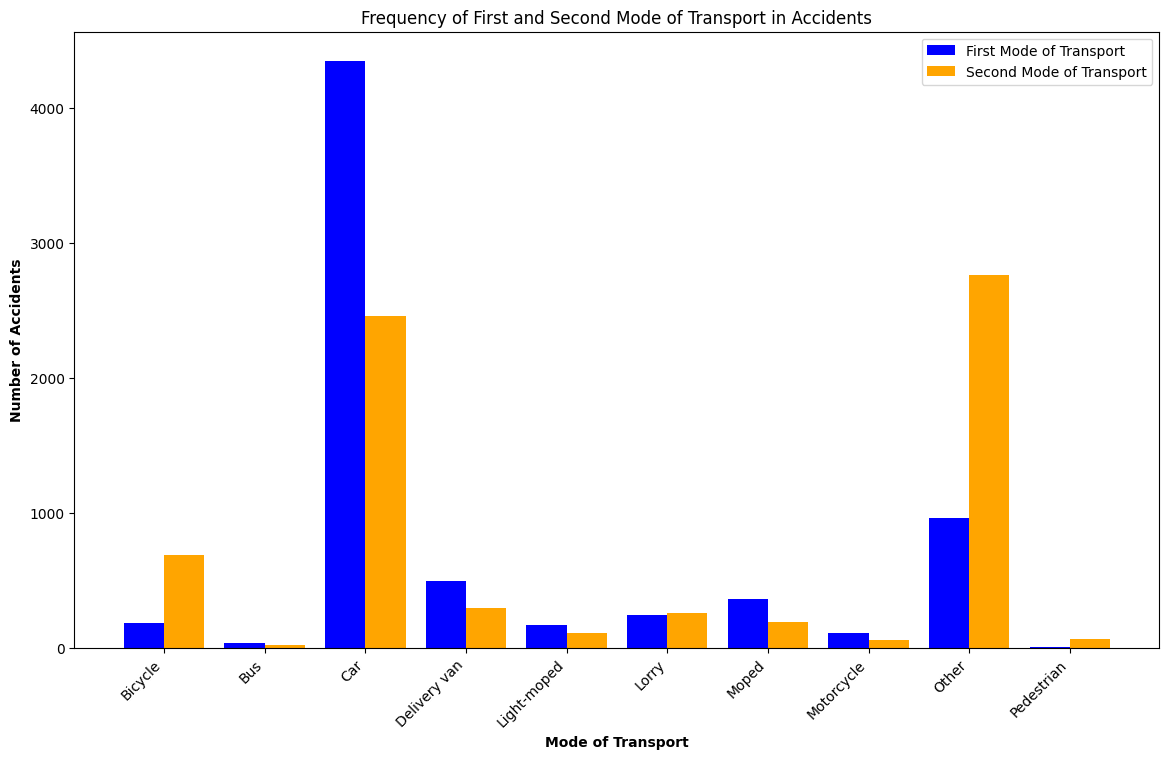

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate the number of accidents per first and second mode of transport
first_mode_counts = new_accidents['First mode of transport'].value_counts().sort_index()
second_mode_counts = new_accidents['Second mode of transport'].value_counts().sort_index()

# Combine the counts into a single DataFrame, aligning the indexes
combined_modes = pd.DataFrame({
    'First Mode': first_mode_counts,
    'Second Mode': second_mode_counts
}).fillna(0).astype(int) 

# Reset the index to convert it from row index to a column
combined_modes = combined_modes.reset_index().rename(columns={'index': 'Mode of Transport'})

# Set the width of each bar
bar_width = 0.4

# Set the positions of the bars on the x-axis
r1 = range(len(combined_modes))
r2 = [x + bar_width for x in r1]

# Plotting the bar chart
plt.figure(figsize=(14, 8))

# Plot first mode of transport counts
plt.bar(r1, combined_modes['First Mode'], color='blue', width=bar_width, label='First Mode of Transport')

# Plot second mode of transport counts next to the first mode bars
plt.bar(r2, combined_modes['Second Mode'], color='orange', width=bar_width, label='Second Mode of Transport')

# Add labels and title
plt.xlabel('Mode of Transport', fontweight='bold')
plt.ylabel('Number of Accidents', fontweight='bold')
plt.xticks([r + bar_width/2 for r in range(len(combined_modes))], combined_modes['Mode of Transport'], rotation=45, ha='right')

plt.title('Frequency of First and Second Mode of Transport in Accidents')
plt.legend(loc='upper right')

plt.show()

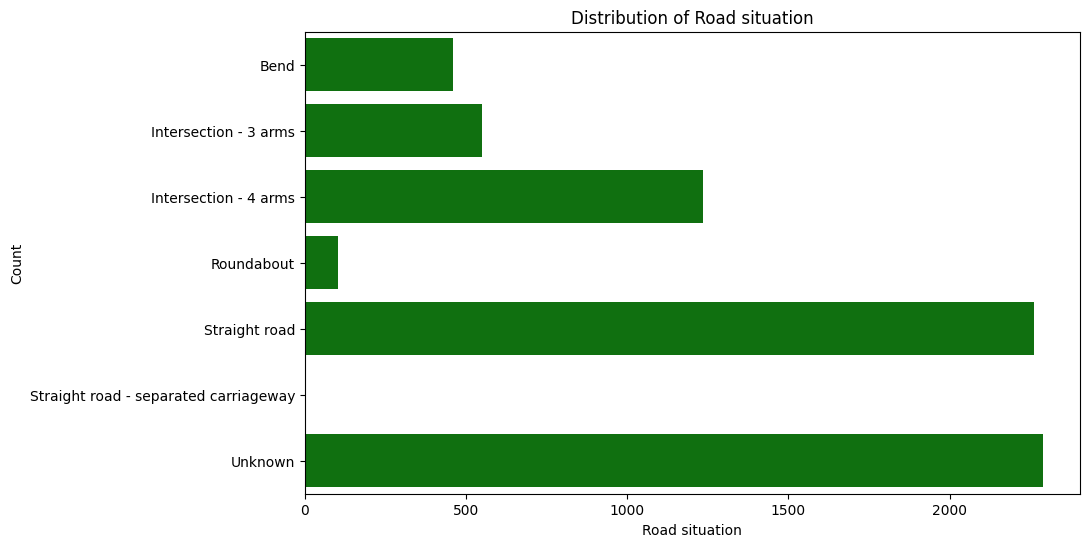

In [23]:
# Distribution of Road situation
plt.figure(figsize=(10, 6))
sns.countplot(y = 'Road situation', data=new_accidents, color = "green")
plt.title('Distribution of Road situation')
plt.xlabel('Road situation')
plt.ylabel('Count')
plt.show()

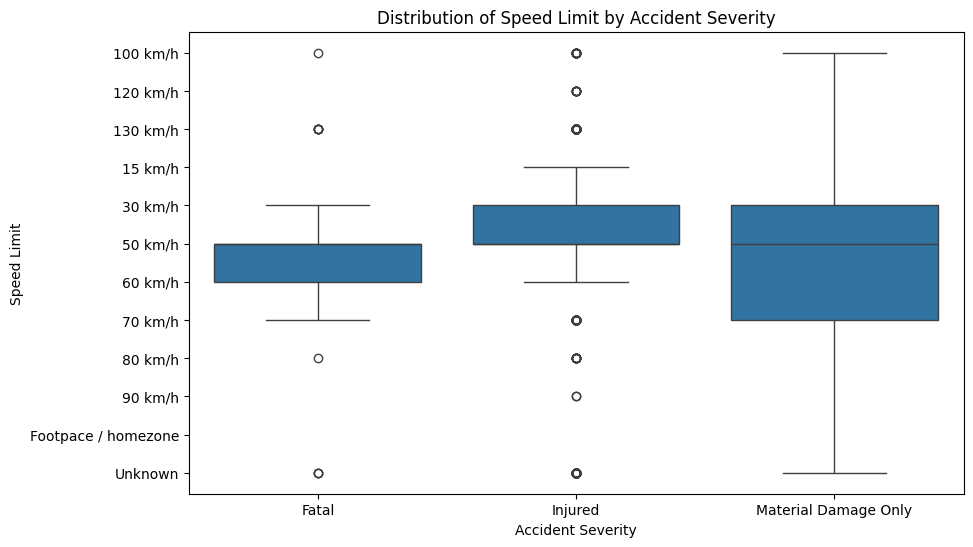

In [24]:
# Distribution of Speed Limit by Accident Severity
plt.figure(figsize=(10, 6))
sns.boxplot(x='Accident severity', y='Speed limit', data=new_accidents)
plt.title('Distribution of Speed Limit by Accident Severity')
plt.xlabel('Accident Severity')
plt.ylabel('Speed Limit')
plt.show()

## Bivariate Analysis

INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


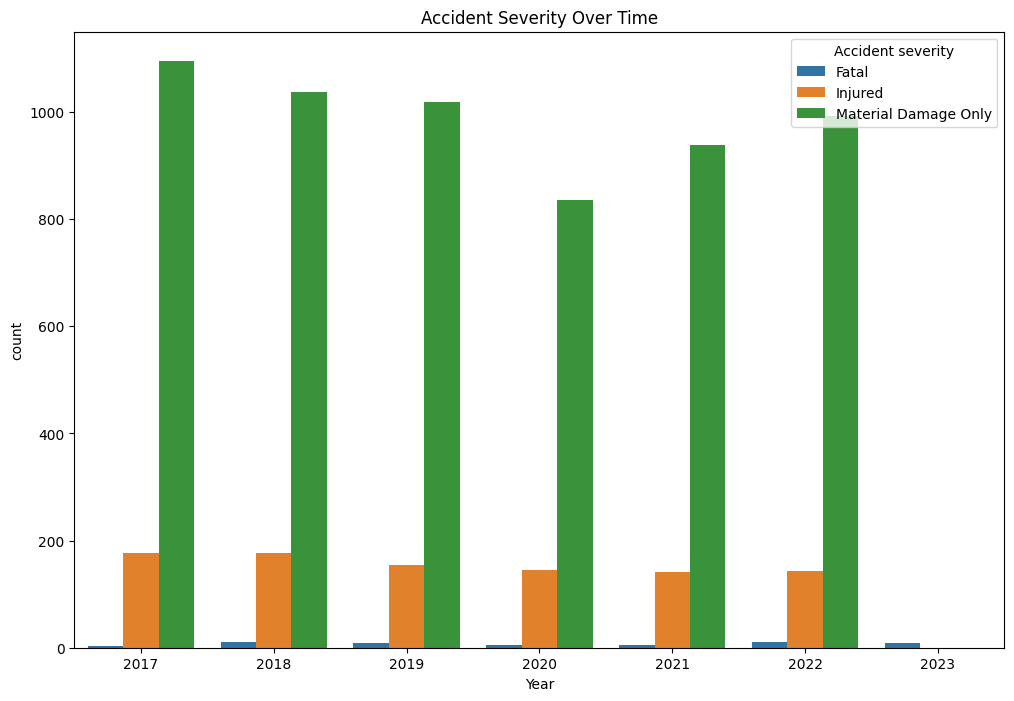

In [25]:
# Accident Severity Over Time
plt.figure(figsize=(12, 8))
sns.countplot(x='Year', hue='Accident severity', data=new_accidents)
plt.title('Accident Severity Over Time')
plt.show()

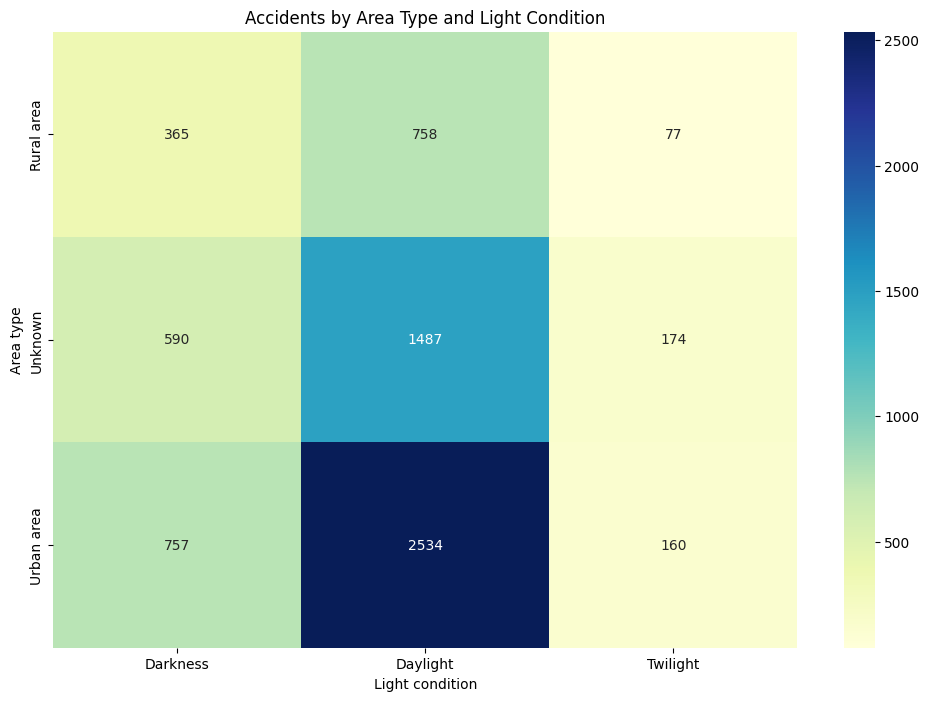

In [26]:
# Accidents by Area Type and Light Condition
plt.figure(figsize=(12, 8))
sns.heatmap(pd.crosstab(new_accidents['Area type'], new_accidents['Light condition']), annot=True, fmt='d', cmap='YlGnBu')
plt.title('Accidents by Area Type and Light Condition')
plt.show()

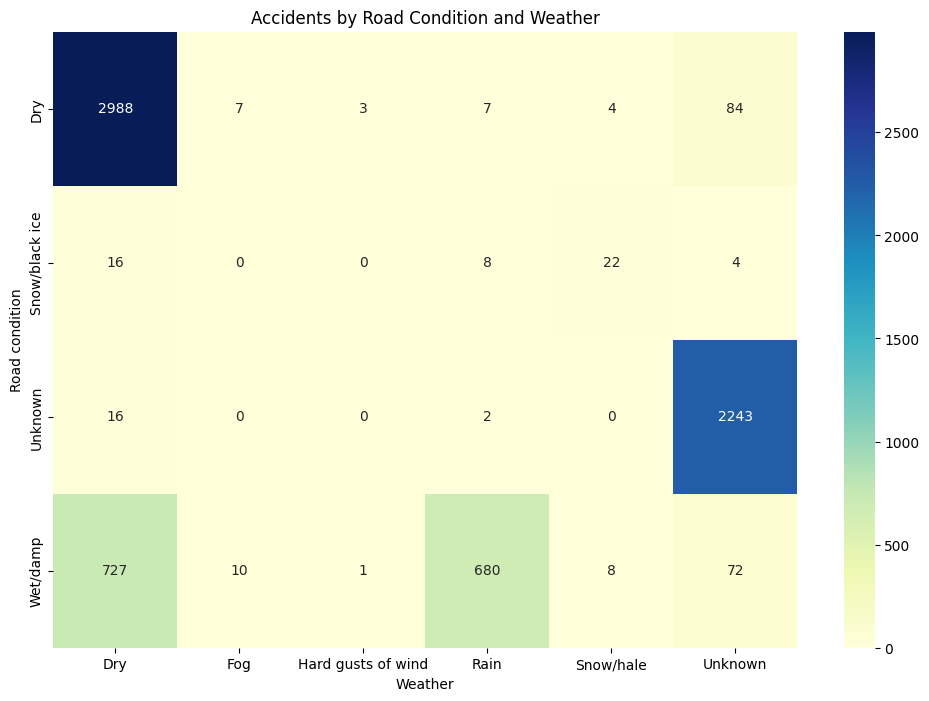

In [27]:
# Accidents by Road Condition and Weather
plt.figure(figsize=(12, 8))
sns.heatmap(pd.crosstab(new_accidents['Road condition'], new_accidents['Weather']), annot=True, fmt='d', cmap='YlGnBu')
plt.title('Accidents by Road Condition and Weather')
plt.show()

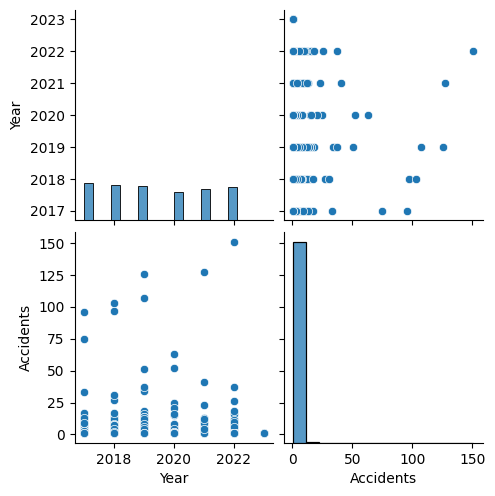

In [28]:
# Pairplot for Numeric Variables
sns.pairplot(new_accidents[['Year', 'Accidents']])
plt.show()

## Multivariate Analysis

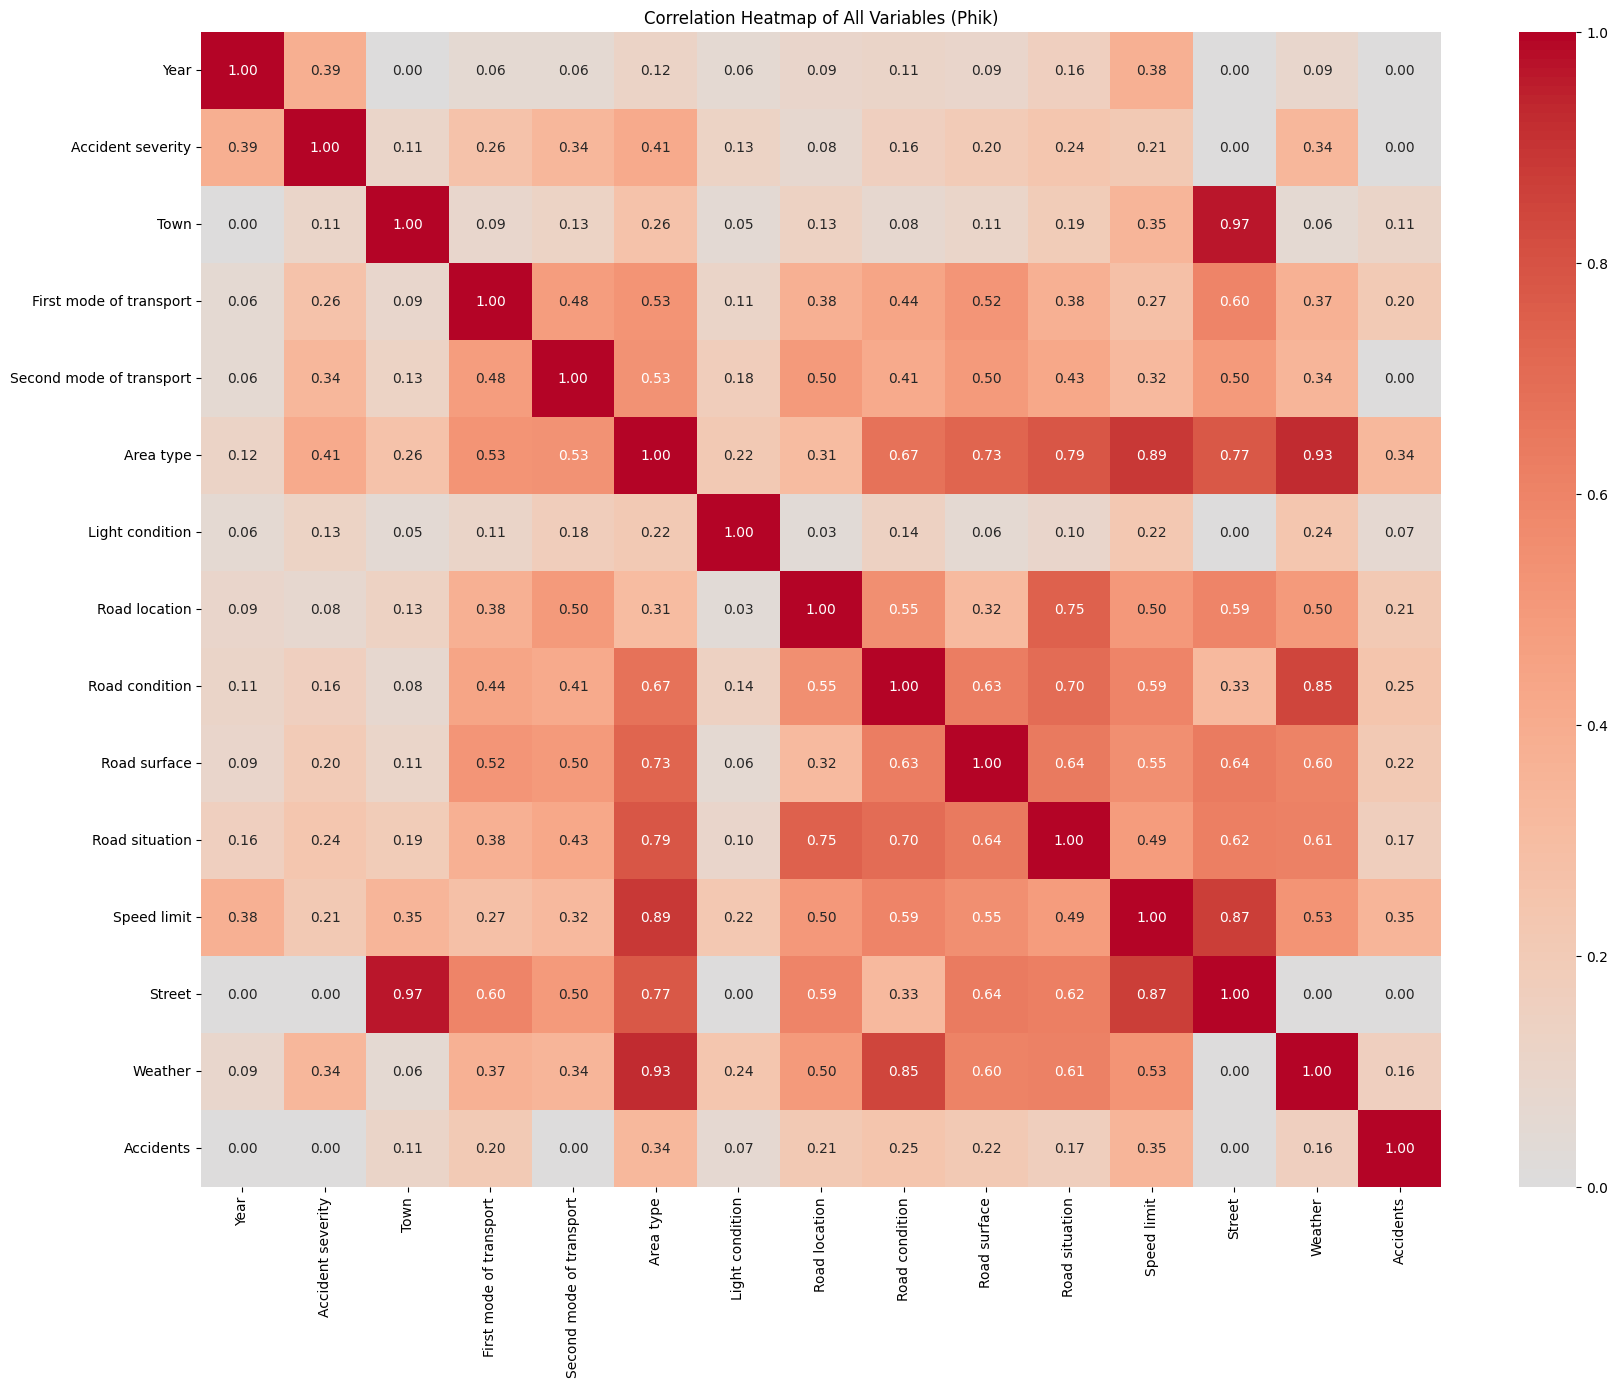

In [29]:
import pandas as pd
import phik
from phik import resources
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings
warnings.filterwarnings('ignore', category=UserWarning)

# Calculate the correlation matrix using phik
phik_matrix = new_accidents.phik_matrix(interval_cols=[])

# Create the heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(phik_matrix.values, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            xticklabels=phik_matrix.columns, yticklabels=phik_matrix.index)
plt.title('Correlation Heatmap of All Variables (Phik)')
plt.show()

## Categorical Data Analysis

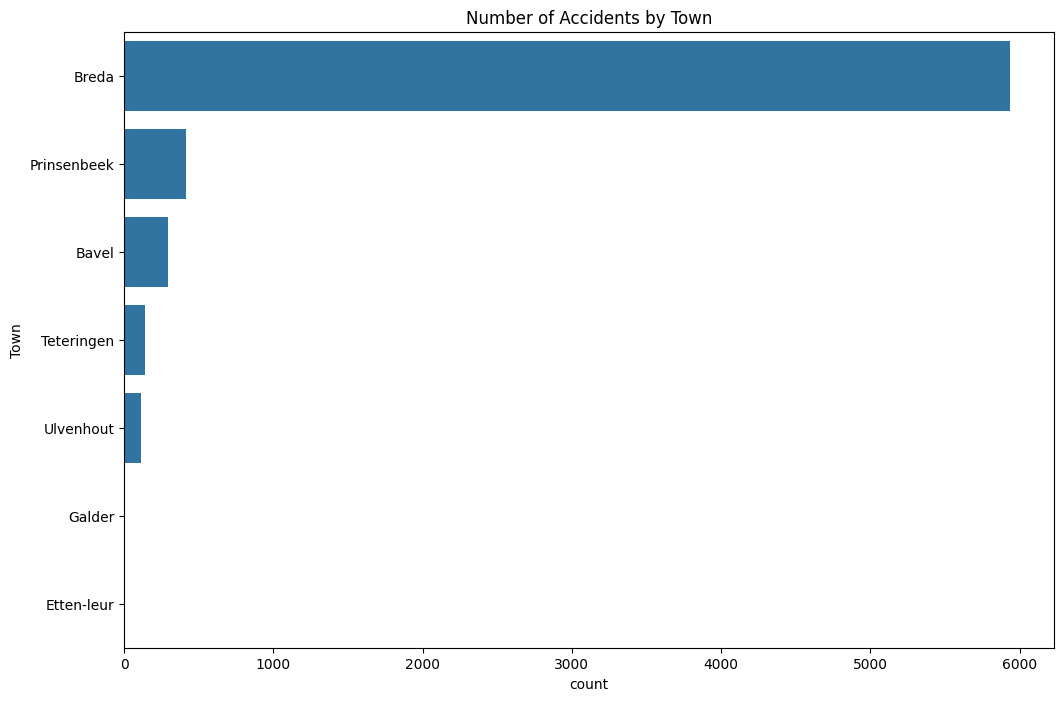

In [30]:
# Accidents by Town
plt.figure(figsize=(12, 8))
sns.countplot(y='Town', data=new_accidents, order=new_accidents['Town'].value_counts().index)
plt.title('Number of Accidents by Town')
plt.show()

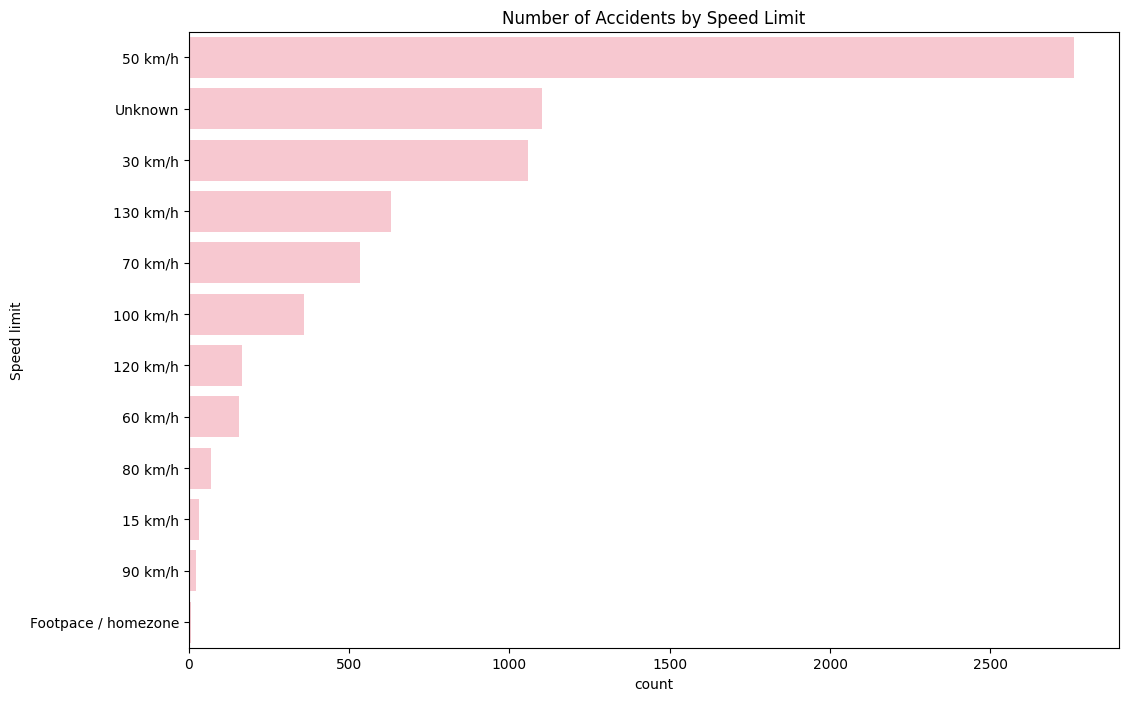

In [31]:
# Accidents by Speed Limit
plt.figure(figsize=(12, 8))
sns.countplot(y='Speed limit', data=new_accidents, color = "pink", order=new_accidents['Speed limit'].value_counts().index)
plt.title('Number of Accidents by Speed Limit')
plt.show()

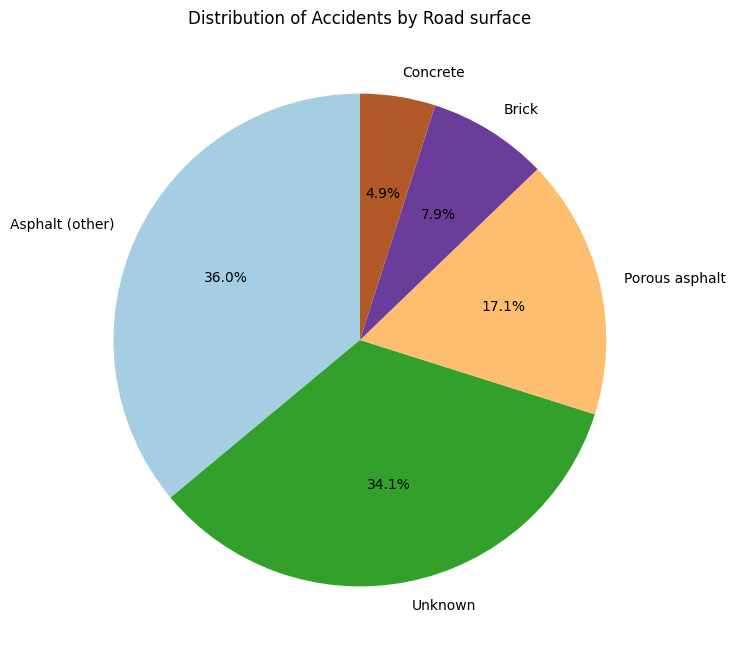

In [32]:
# Distribution of Accidents by Road surface
plt.figure(figsize=(8, 8))
new_accidents['Road surface'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, cmap='Paired')
plt.title('Distribution of Accidents by Road surface')
plt.ylabel('')
plt.show()

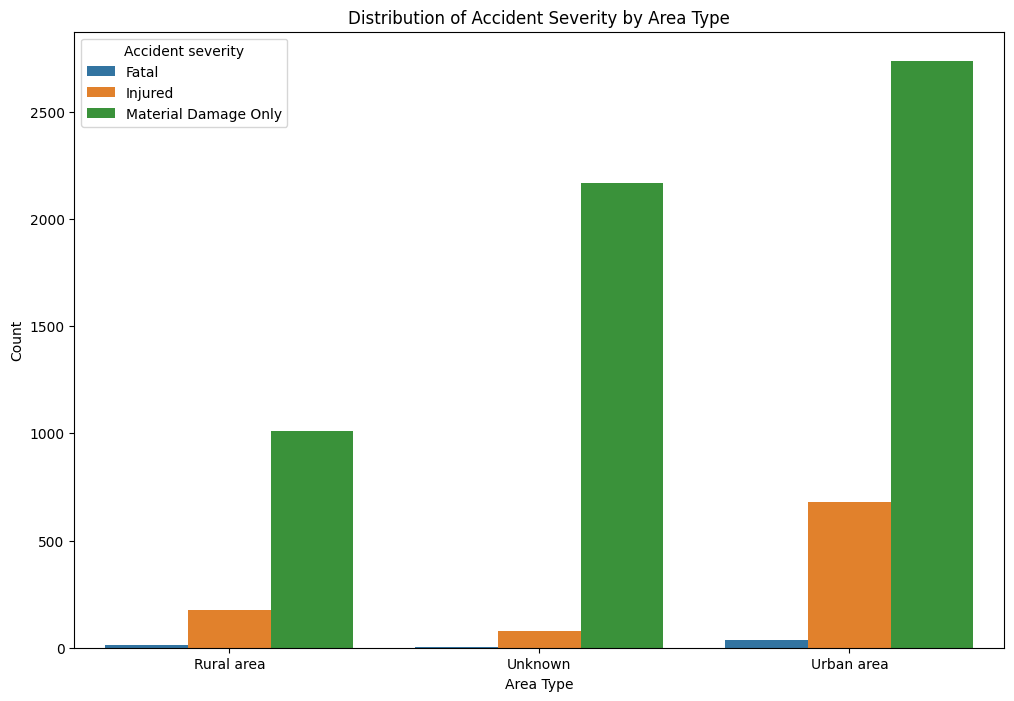

In [33]:
# Distribution of Accident Severity by Area Type
plt.figure(figsize=(12, 8))
sns.countplot(x='Area type', hue='Accident severity', data=new_accidents)
plt.title('Distribution of Accident Severity by Area Type')
plt.xlabel('Area Type')
plt.ylabel('Count')
plt.legend(title='Accident severity')
plt.show()

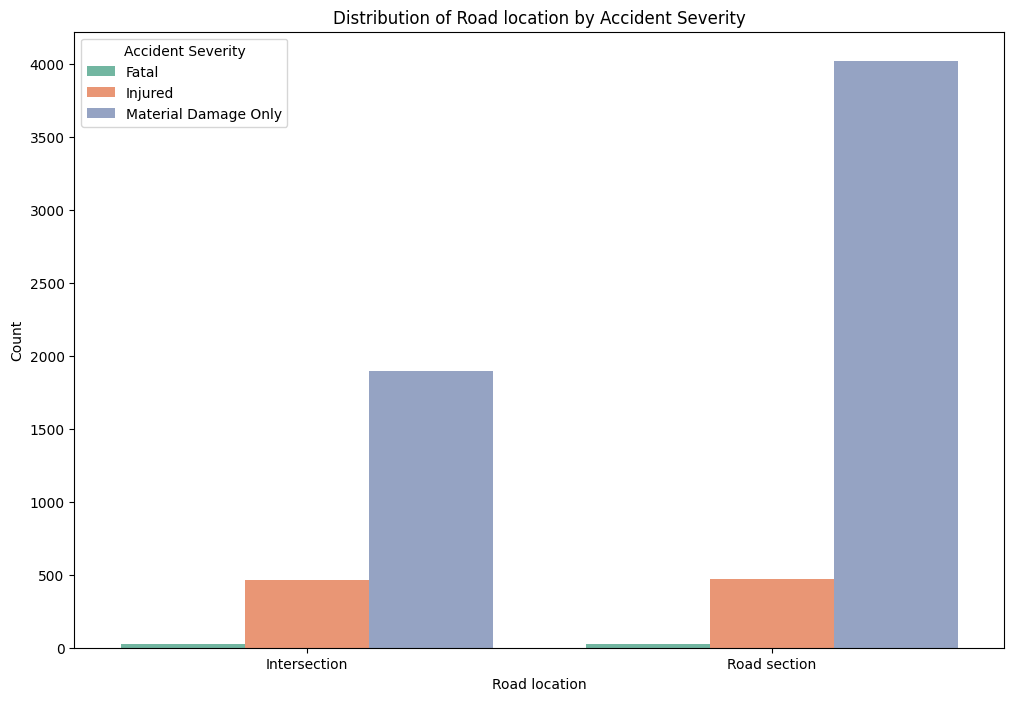

In [34]:
# Distribution of Accident Severity by Road location
plt.figure(figsize=(12, 8))
sns.countplot(x='Road location', hue='Accident severity', data=new_accidents, palette = 'Set2')
plt.title('Distribution of Road location by Accident Severity')
plt.xlabel('Road location')
plt.ylabel('Count')
plt.legend(title='Accident Severity')
plt.show()

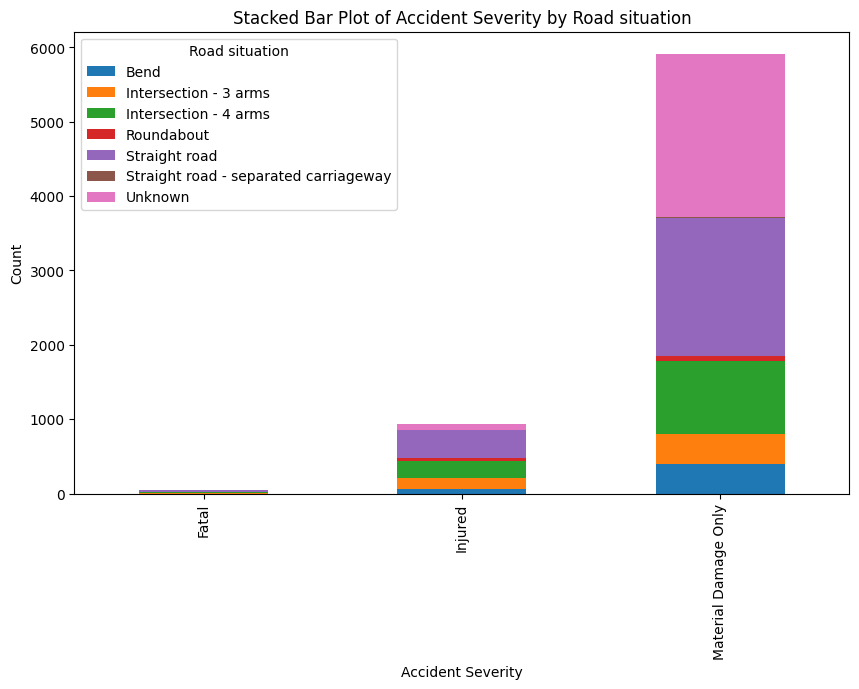

In [35]:
# Stacked Bar Plot of Accident Severity by Weather Condition
table = pd.crosstab(new_accidents['Accident severity'], new_accidents['Road situation'])
table.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Stacked Bar Plot of Accident Severity by Road situation')
plt.xlabel('Accident Severity')
plt.ylabel('Count')
plt.legend(title='Road situation')
plt.show()

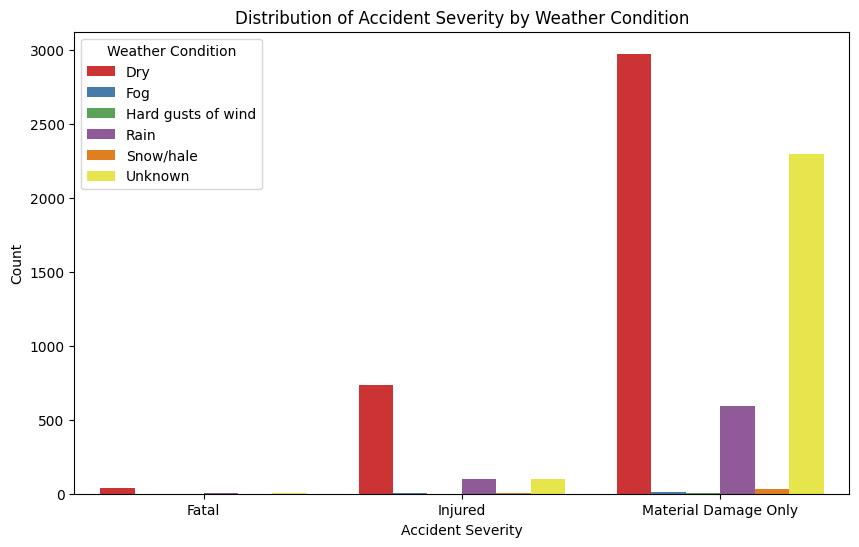

In [36]:
# Distribution of Accident Severity by Weather Condition
plt.figure(figsize=(10, 6))
sns.countplot(x='Accident severity', hue='Weather', data=new_accidents, palette='Set1')
plt.title('Distribution of Accident Severity by Weather Condition')
plt.xlabel('Accident Severity')
plt.ylabel('Count')
plt.legend(title='Weather Condition')
plt.show()

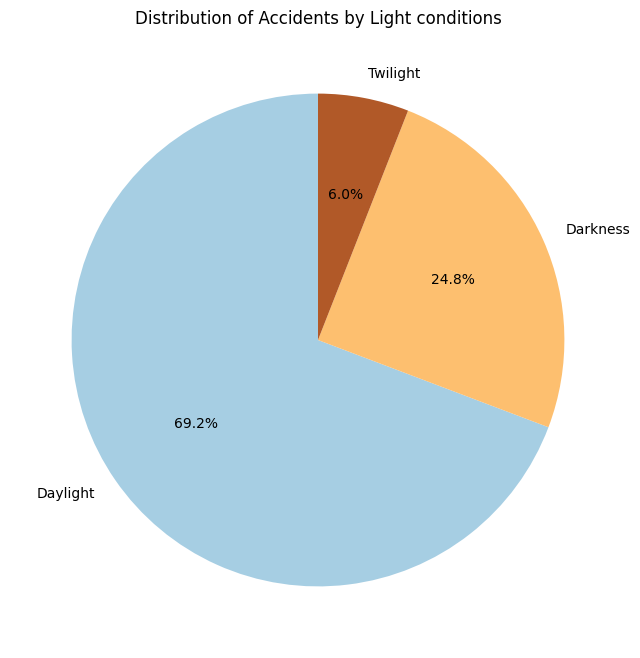

In [37]:
# Distribution of Accidents by Light conditions
plt.figure(figsize=(8, 8))
new_accidents['Light condition'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, cmap='Paired')
plt.title('Distribution of Accidents by Light conditions')
plt.ylabel('')
plt.show()

## Time Series Analysis

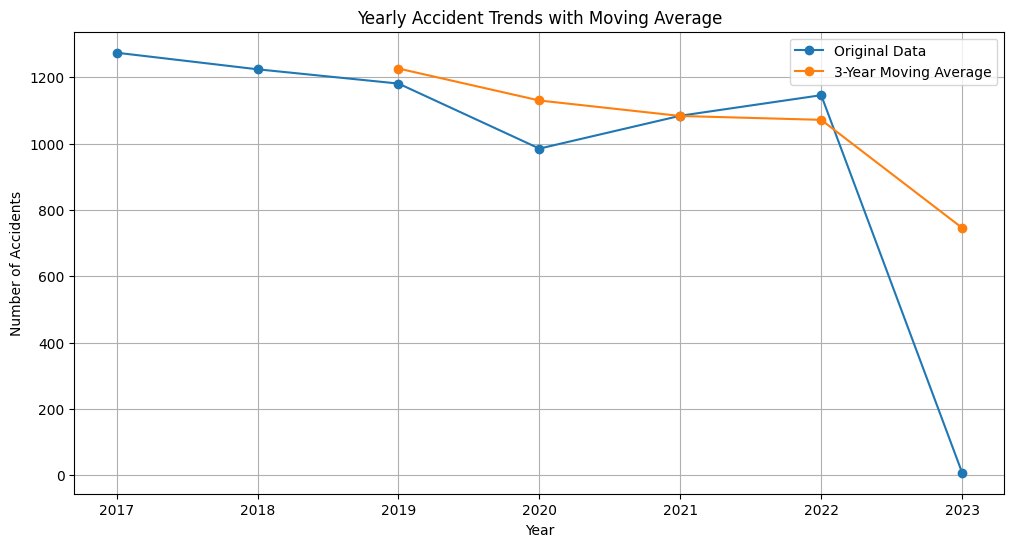

In [38]:
# Yearly Moving Average 
# Group data by year and count the number of accidents each year
yearly_accidents = new_accidents.groupby('Year').size()

# Compute a simple moving average
moving_avg = yearly_accidents.rolling(window=3).mean()

# Plot the moving average along with the original data
plt.figure(figsize=(12, 6))
plt.plot(yearly_accidents, marker='o', label='Original Data')
plt.plot(moving_avg, marker='o', label='3-Year Moving Average')
plt.title('Yearly Accident Trends with Moving Average')
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_3466834/1814588095.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  yearly_severity = new_accidents.groupby(['Year', 'Accident severity']).size().unstack()


<Figure size 1200x600 with 0 Axes>

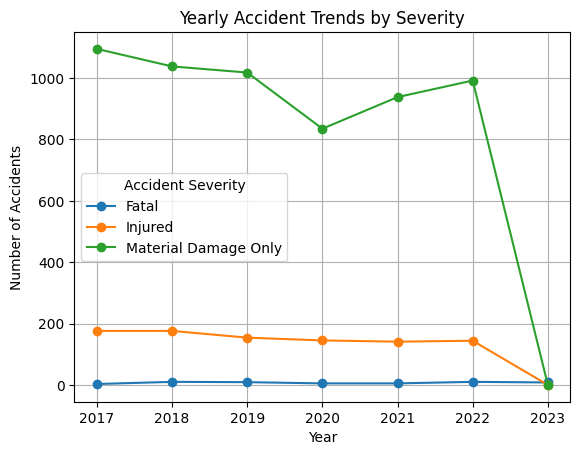

In [39]:
# Yearly Trends by Severity
# Group by year and severity and count the number of accidents
yearly_severity = new_accidents.groupby(['Year', 'Accident severity']).size().unstack()

# Plot the trends
plt.figure(figsize=(12, 6))
yearly_severity.plot(marker='o')
plt.title('Yearly Accident Trends by Severity')
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.legend(title='Accident Severity')
plt.grid(True)
plt.show()

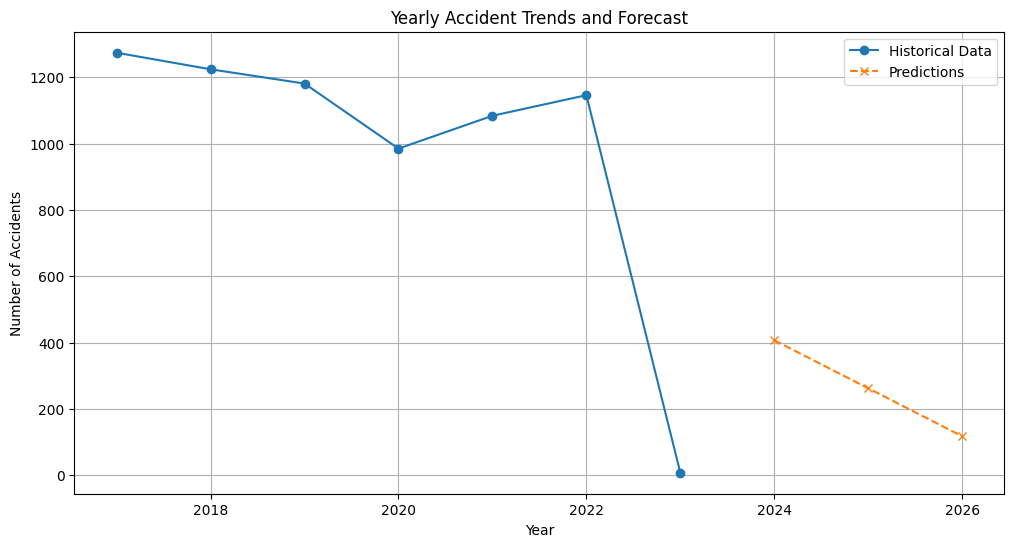

In [40]:
# Forecasting
import numpy as np
from sklearn.linear_model import LinearRegression

# Prepare the data
X = np.array(yearly_accidents.index).reshape(-1, 1)  # Years as X
y = yearly_accidents.values  # Number of accidents as y

# Train a simple linear regression model
model = LinearRegression()
model.fit(X, y)

# Predict future values
future_years = np.array([2024, 2025, 2026]).reshape(-1, 1)
predictions = model.predict(future_years)

# Plot the historical data and the predictions
plt.figure(figsize=(12, 6))
plt.plot(yearly_accidents, marker='o', label='Historical Data')
plt.plot(future_years, predictions, marker='x', linestyle='--', label='Predictions')
plt.title('Yearly Accident Trends and Forecast')
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.legend()
plt.grid(True)
plt.show()

## Saving the preprocessed dataset into a table

In [41]:
import pandas as pd
import psycopg2
from psycopg2 import sql

table_name = 'new_accidents_preprocessed'
schema_name = 'group15_warehouse'

# Drop table if it exists (optional)
print("Attempting to drop existing table if it exists.")
drop_table_query = sql.SQL("DROP TABLE IF EXISTS {}.{};").format(
    sql.Identifier(schema_name), sql.Identifier(table_name)
)
cursor.execute(drop_table_query)
conn_psycopg2.commit()
print("Existing table dropped if it existed.")

# Create table in the specified schema
print("Creating new table.")
create_table_query = sql.SQL('''
    CREATE TABLE {}.{} (
        "Year" INT,
        "Accident severity" VARCHAR(50),
        "Town" VARCHAR(100),
        "First mode of transport" VARCHAR(50),
        "Second mode of transport" VARCHAR(50),
        "Area type" VARCHAR(50),
        "Light condition" VARCHAR(50),
        "Road location" VARCHAR(50),
        "Road condition" VARCHAR(50),
        "Road surface" VARCHAR(50),
        "Road situation" VARCHAR(50),
        "Speed limit" VARCHAR(50),
        "Street" VARCHAR(100),
        "Weather" VARCHAR(50),
        "Accidents" INT
    )
''').format(
    sql.Identifier(schema_name), sql.Identifier(table_name)
)
cursor.execute(create_table_query)
conn_psycopg2.commit()
print("New table created.")

# Prepare data for insertion
print("Preparing data for insertion.")
data_tuples = [tuple(row) for row in new_accidents.values]
print(f"Prepared {len(data_tuples)} rows of data for insertion.")

# Insert DataFrame records into PostgreSQL table
print("Inserting data into the new table.")
insert_query = sql.SQL("INSERT INTO {}.{} VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)").format(
    sql.Identifier(schema_name), sql.Identifier(table_name)
)
cursor.executemany(insert_query, data_tuples)

# Commit changes
conn_psycopg2.commit()
print("Data inserted successfully.")


print("DataFrame saved to PostgreSQL successfully.")

Attempting to drop existing table if it exists.
Existing table dropped if it existed.
Creating new table.
New table created.
Preparing data for insertion.
Prepared 6902 rows of data for insertion.
Inserting data into the new table.
Data inserted successfully.
DataFrame saved to PostgreSQL successfully.


## Closing the connection

In [42]:
# Close cursor and connection
cursor.close()
conn_psycopg2.close()
print("Database connection closed.")

Database connection closed.
